# Crosscorrelation- Turning angle and error angle (250 fps) 


Processing: Trial2_180rpmxyzpts
  ⚠ Too few points

Processing: Trial2_200rpmxyzpts
  ⚠ Too few points

Processing: Trial3_180rpmxyzpts
  ⚠ Too few points

Processing: Trial4_400rpmxyzpts
  ⚠ Too few points

Processing: Trial5_180rpmxyzpts
  ⚠ Too few points

Processing: Trial5_400rpmxyzpts
  ⚠ Too few points

Processing: Trial7_400rpmxyzpts
  → Peak lag: 0.1000 sec


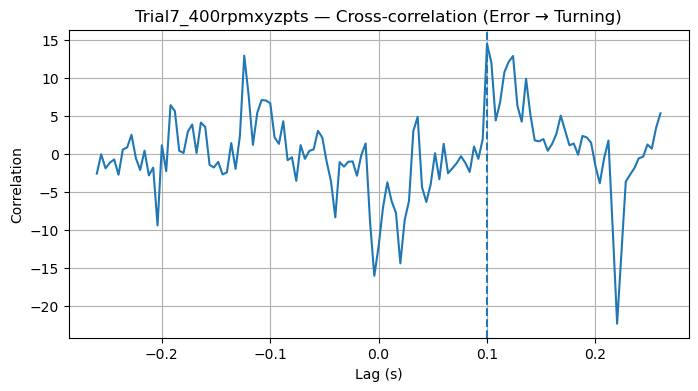

In [1]:
import numpy as np
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

# ── PATHS ─────────────────────────────────────────────────────────────
ERR_DIR  = r"./../../dataFolders/MuscaChasingBeads/ErrorAngle_DistFromBead/ErrorAngle_DistFromBead_Subsampled"
TURN_DIR = r"./../../dataFolders/MuscaChasingBeads/turning_angle/subsample_turning_angle_center-based"

FPS = 250

# ── FUNCTION ──────────────────────────────────────────────────────────
def compute_cross_correlation(x, y):
    # remove mean (VERY important)
    x = x - np.nanmean(x)
    y = y - np.nanmean(y)

    # normalize (optional but recommended)
    x = x / (np.nanstd(x) + 1e-8)
    y = y / (np.nanstd(y) + 1e-8)

    corr = np.correlate(x, y, mode='full')
    lags = np.arange(-len(x)+1, len(x))

    return corr, lags

# ── LOOP THROUGH TRIALS ───────────────────────────────────────────────
err_files = glob.glob(os.path.join(ERR_DIR, "*_CHASE_METRICS.csv"))

for err_path in err_files:
    fname = os.path.basename(err_path)
    trial = fname.replace("_CHASE_METRICS.csv", "")

    print(f"\nProcessing: {trial}")

    turn_path = os.path.join(TURN_DIR, f"{trial}_TURNING_ANGLE.csv")

    if not os.path.exists(turn_path):
        print("  ⚠ No matching turning file")
        continue

    df_err  = pd.read_csv(err_path)
    df_turn = pd.read_csv(turn_path)

    # ── Choose signals ────────────────────────────────────────────────
    error = df_err["error_angle_horiz_unwrapped_deg"].values
    turn  = df_turn["turning_angle_xy_unwrapped_deg"].values

    # ── ALIGN LENGTHS ─────────────────────────────────────────────────
    min_len = min(len(error), len(turn))
    error = error[:min_len]
    turn  = turn[:min_len]

    # ── REMOVE NaNs ───────────────────────────────────────────────────
    valid = np.isfinite(error) & np.isfinite(turn)
    error = error[valid]
    turn  = turn[valid]

    if len(error) < 50:
        print("  ⚠ Too few points")
        continue

    # ── CROSS-CORRELATION ─────────────────────────────────────────────
    corr, lags = compute_cross_correlation(error, turn)

    # convert lag to time
    lag_time = lags / FPS

    # ── FIND PEAK ─────────────────────────────────────────────────────
    peak_idx = np.argmax(corr)
    peak_lag = lag_time[peak_idx]

    print(f"  → Peak lag: {peak_lag:.4f} sec")

    # ── PLOT ──────────────────────────────────────────────────────────
    plt.figure(figsize=(8,4))
    plt.plot(lag_time, corr)
    plt.axvline(peak_lag, linestyle="--")
    plt.title(f"{trial} — Cross-correlation (Error → Turning)")
    plt.xlabel("Lag (s)")
    plt.ylabel("Correlation")
    plt.grid(True)
    plt.show()

# Crosscorrelation- Turning angle and error angle (1000 fps) 


Processing: Trial2_180rpmxyzpts
  ⚠ Too few points

Processing: Trial2_200rpmxyzpts
  → Peak lag: -0.0040 sec


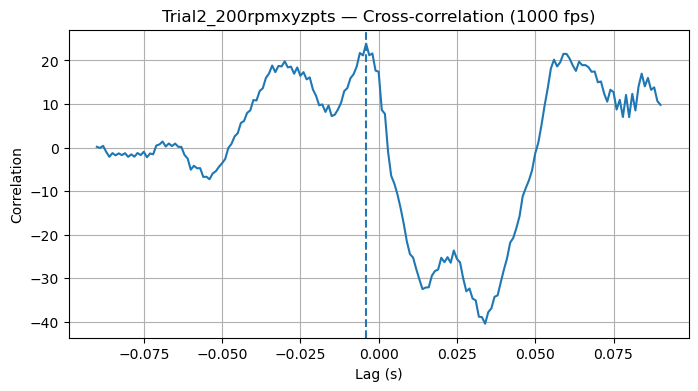


Processing: Trial3_180rpmxyzpts
  → Peak lag: 0.0770 sec


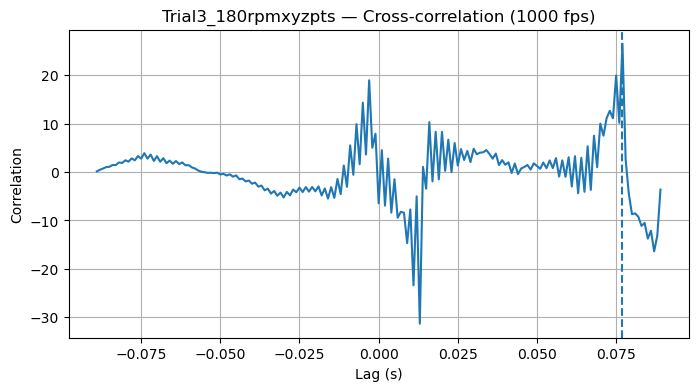


Processing: Trial4_400rpmxyzpts
  → Peak lag: 0.0010 sec


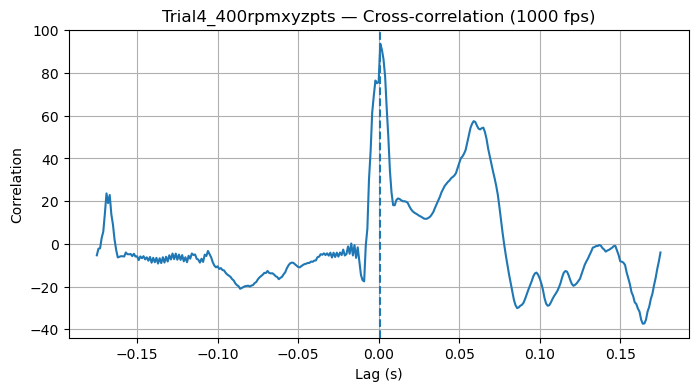


Processing: Trial5_180rpmxyzpts
  ⚠ Too few points

Processing: Trial5_400rpmxyzpts
  ⚠ Too few points

Processing: Trial7_400rpmxyzpts
  → Peak lag: -0.1360 sec


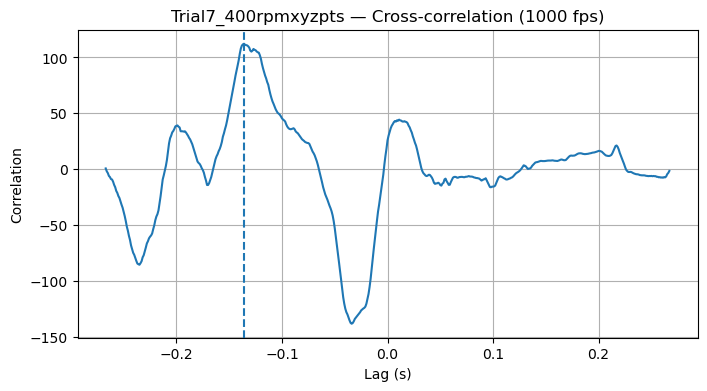

In [2]:
import numpy as np
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

# ── PATHS (1000 fps) ─────────────────────────────────────────────────
ERR_DIR  = r"./../../dataFolders/MuscaChasingBeads/ErrorAngle_DistFromBead/ErrorAngle_DistFromBead_Subsampled_1000fps"
TURN_DIR = r"./../../dataFolders/MuscaChasingBeads/turning_angle/subsample_turning_angle_center-based_1000fps"

FPS = 1000

# ── FUNCTION ─────────────────────────────────────────────────────────
def compute_cross_correlation(x, y):
    x = x - np.nanmean(x)
    y = y - np.nanmean(y)

    x = x / (np.nanstd(x) + 1e-8)
    y = y / (np.nanstd(y) + 1e-8)

    corr = np.correlate(x, y, mode='full')
    lags = np.arange(-len(x)+1, len(x))

    return corr, lags

# ── LOOP ─────────────────────────────────────────────────────────────
err_files = glob.glob(os.path.join(ERR_DIR, "*_CHASE_METRICS_1000fps.csv"))

for err_path in err_files:
    fname = os.path.basename(err_path)
    trial = fname.replace("_CHASE_METRICS_1000fps.csv", "")

    print(f"\nProcessing: {trial}")

    turn_path = os.path.join(TURN_DIR, f"{trial}_TURNING_ANGLE_1000fps.csv")

    if not os.path.exists(turn_path):
        print("  ⚠ No matching turning file")
        continue

    df_err  = pd.read_csv(err_path)
    df_turn = pd.read_csv(turn_path)

    # ── Signals ──────────────────────────────────────────────────────
    error = df_err["error_angle_horiz_unwrapped_deg"].values
    turn  = df_turn["turning_angle_xy_unwrapped_deg"].values

    # ── ALIGN LENGTHS ────────────────────────────────────────────────
    min_len = min(len(error), len(turn))
    error = error[:min_len]
    turn  = turn[:min_len]

    # ── REMOVE NaNs (no interpolation) ───────────────────────────────
    valid = np.isfinite(error) & np.isfinite(turn)
    error = error[valid]
    turn  = turn[valid]

    if len(error) < 50:
        print("  ⚠ Too few points")
        continue

    # ── CROSS-CORRELATION ────────────────────────────────────────────
    corr, lags = compute_cross_correlation(error, turn)

    lag_time = lags / FPS

    # ── PEAK ─────────────────────────────────────────────────────────
    peak_idx = np.argmax(corr)
    peak_lag = lag_time[peak_idx]

    print(f"  → Peak lag: {peak_lag:.4f} sec")

    # ── PLOT ─────────────────────────────────────────────────────────
    plt.figure(figsize=(8,4))
    plt.plot(lag_time, corr)
    plt.axvline(peak_lag, linestyle="--")
    plt.title(f"{trial} — Cross-correlation (1000 fps)")
    plt.xlabel("Lag (s)")
    plt.ylabel("Correlation")
    plt.grid(True)
    plt.show()